In [1]:
using CSV, DataFrames, Dates, Gadfly, Distributions, IDFCurves, LsqFit, Statistics, Extremes, Cairo

In [2]:
# CLIMEX, composé de 50 membres, mais spécifiquemenet au point latitude, longitude Montreal.
"""
    annualmax(durations::Vector{<:Real}, all::Bool = true, writeOut::Bool = false)

    Annual maximum of array data.
    Hourly time series. Extract the highest value for year i.
"""
function annualmax(durations::Vector{<:Real}, all::Bool = true, writeOut::Bool = false)
    folder_path = "data/climEx_hrs"
    csv_dict = Dict{String, DataFrame}()
    csv_files = filter(x -> occursin(".csv", x), readdir(folder_path))

    for file in csv_files
        # Initialize an empty DataFrame for storing results
        final_df = DataFrame()

        for duration in durations
            file_path = joinpath(folder_path, file)
            climex_df = CSV.read(file_path, DataFrame)

            df_daily_agg = combine(groupby(transform(climex_df, :Date => ByRow(x->round(x, Dates.Hour(duration), RoundDown)) => :Grouped_Period, renamecols=false),  :Grouped_Period), :Pluie=>sum=>:Pluie)
            df_daily_agg = transform(df_daily_agg, :Grouped_Period => ByRow(x -> Dates.year(x)) => :Year, :Grouped_Period => ByRow(x -> Dates.month(x)) => :Month, copycols=false)
            numYears = unique(df_daily_agg[!,:Year])

            # Filter for months May (5) to October (10)
            df_daily_agg = filter(row -> row.Month >= 5 && row.Month <= 10, df_daily_agg)

            annual_maxima = zeros(length(numYears))
            for i in 1:(length(numYears))
                idx = searchsortedfirst(df_daily_agg[!,:Year], numYears[i]):searchsortedlast(df_daily_agg[!,:Year], numYears[i])
                annual_maxima[i] = Statistics.maximum(df_daily_agg[idx,:Pluie])
            end

            maxima_col = string("Maxima $(duration)h")
            df_annual_maxima = DataFrame(Year = numYears, Maxima = annual_maxima)
            df_annual_maxima = rename(df_annual_maxima, :Maxima => maxima_col)
            df_annual_maxima[!, maxima_col] = Float64.(df_annual_maxima[!, maxima_col]) ./ duration

            if writeOut
                CSV.write(string("$(duration)h.csv"), df_annual_maxima)
            end

            # Combine with final DataFrame
            if ncol(final_df) == 0
                final_df = df_annual_maxima
            else
                final_df = outerjoin(final_df, df_annual_maxima, on=:Year, makeunique=true)
            end
            clean_df = dropmissing(final_df)
            csv_dict[file] = clean_df

        end

        if !all
            break
        end
    end

    return csv_dict
end 

df_annual_maxima = annualmax([1,2,6,12,24], true)

Dict{String, DataFrame} with 50 entries:
  "keh.csv" => 145×6 DataFrame…
  "kdu.csv" => 145×6 DataFrame…
  "kel.csv" => 145×6 DataFrame…
  "kdi.csv" => 145×6 DataFrame…
  "kes.csv" => 145×6 DataFrame…
  "kdp.csv" => 145×6 DataFrame…
  "kex.csv" => 145×6 DataFrame…
  "kds.csv" => 145×6 DataFrame…
  "kdg.csv" => 145×6 DataFrame…
  "kde.csv" => 145×6 DataFrame…
  "kew.csv" => 145×6 DataFrame…
  "kei.csv" => 145×6 DataFrame…
  "kef.csv" => 145×6 DataFrame…
  "kej.csv" => 145×6 DataFrame…
  "kea.csv" => 145×6 DataFrame…
  "keb.csv" => 145×6 DataFrame…
  "ker.csv" => 145×6 DataFrame…
  "kdw.csv" => 145×6 DataFrame…
  "kdc.csv" => 145×6 DataFrame…
  ⋮         => ⋮

In [3]:
function intensity_idf(fd::DependentScalingModel, return_period, duration, year::Int=0)
    # 1 - 1/return_period
    depth = quantile(getmarginalmodel(fd), duration/60, 1 - 1/return_period, year)

    return depth
end

# Function to fit the IDF curve parameters A, B, and C
function fit_idf_parameters(durations::Vector{Float64}, intensities::Vector{Float64})
    # I = A / (t + B)^C
    idf_model(t, p) = p[1] ./ (t .+ p[2]).^p[3]

    initial_params = [1000.0, 10.0, 0.5]

    fit = curve_fit(idf_model, durations, intensities, initial_params)
    A, B, C = fit.param
    return A, B, C
end

fit_idf_parameters (generic function with 1 method)

In [4]:
function idf_intensity(A::Float64, B::Float64, C::Float64, duration::Float64)
    # I = A / (t + B)^C
    intensity = A / (duration + B)^C
    return intensity
end

# Function to create a Chicago-style hyetograph using the alternating block method
function chicago_hyetograph_from_idf(A::Float64, B::Float64, C::Float64, return_period, storm_duration, time_step, peak_time)
    """
    Create a Chicago-style hyetograph based on IDF curve parameters.

    Parameters:
    - A, B, C: IDF curve parameters
    - return_period: The return period for the extreme rainfall event (not used directly here but could be part of more complex logic)
    - storm_duration: Total duration of the storm (minutes)
    - time_step: Time step for the hyetograph (minutes)
    - peak_time: Time at which the peak rainfall intensity occurs (minutes)

    Returns:
    - DataFrame containing the time and rainfall intensity for each time step
    """

    num_steps = Int(storm_duration / time_step)
    durations = collect(0.0:time_step:storm_duration)
    intensities = [idf_intensity(A, B, C, d) for d in durations if d > 0]

    num_intensities = length(intensities)
    rainfall_distribution = zeros(num_intensities)
    peak_index = Int(peak_time / time_step)

    # Alternating block arrangement: place highest intensity at peak, then alternate lower values before and after
    sorted_intensities = sort(intensities, rev=true)
    for i in 1:num_intensities
        if i % 2 == 1
            index = peak_index - (i ÷ 2)
        else
            index = peak_index + (i ÷ 2)
        end
        if index > 0 && index <= num_intensities
            rainfall_distribution[index] = sorted_intensities[i]
        end
    end

    cumulative_depth = []
    current_sum = 0.0
    for i in 1:num_intensities
        # Calculate depth for this step
        depth = rainfall_distribution[i] * (time_step / 60.0)  # Convert time step to hours
        current_sum += depth
        push!(cumulative_depth, current_sum)
    end

    # Get the total depth (last value in cumulative depth)
    total_depth = current_sum

    # Normalize to get cumulative depth percentage
    cumulative_depth_percentage = []
    for i in 1:num_intensities
        if total_depth > 0
            push!(cumulative_depth_percentage, (cumulative_depth[i] / total_depth) * 100.0)
        else
            push!(cumulative_depth_percentage, 0.0)  # Handle case where total depth is 0
        end
    end

    return DataFrame(Time = durations[1:num_intensities], Intensity = rainfall_distribution, CumulativeDepthPercentage = cumulative_depth_percentage)
end

# Function to plot hyetographs for multiple return periods
function plot_hyetographs(dist, return_periods, storm_duration, time_step, peak_time, year=0)
    layers = []
    colors = ["red", "blue", "green", "purple", "orange", "brown"]
    hyetographs = Dict{Float64, DataFrame}()
    durations = [5.0, 10.0, 30.0, 60.0, 120.0, 360.0, 720.0, 1440.0]

    for (i, return_period) in enumerate(return_periods)
        intensities = [intensity_idf(dist, return_period, d, year) for d in durations]

        A, B, C = fit_idf_parameters(durations, intensities)
        
        hyetograph = chicago_hyetograph_from_idf(A, B, C, return_period, storm_duration, time_step, peak_time)
        append!(layers, layer(hyetograph, x=:Time, y=:Intensity, Geom.line, Geom.point, Theme(default_color=colors[i], line_width=2pt)))
        hyetographs[return_period] = hyetograph
    end

    p = plot(layers...,
             Guide.xlabel("Time (minutes)"), 
             Guide.ylabel("Rainfall Intensity (mm/hr)"), 
             Guide.title("Chicago-Style Hyetograph for Multiple Return Periods"),
             Theme(
                panel_fill = color("white"),  # Set the panel background to white
                background_color = color("white")  # Set the overall background to white
             )
    )
    
    p.scales = [
        Scale.y_continuous(minvalue=0, maxvalue=62)
    ]
    return p, hyetographs
end

# Function to calculate the total accumulated rainfall using trapezoidal integration
function calculate_total_rainfall_multiple(hyetographs::Dict{Float64, DataFrame})
    total_rainfall = Dict{Float64, Float64}()

    for (return_period, hyetograph) in hyetographs
        time_in_hours = hyetograph.Time ./ 60.0
        intensity = hyetograph.Intensity

        total_depth = sum(0.5 .* (intensity[2:end] .+ intensity[1:end-1]) .* diff(time_in_hours))

        total_rainfall[return_period] = total_depth
    end

    return total_rainfall
end

# Function to plot cumulative rainfall depth (%) curve for multiple return periods
function plot_cumulative_depth_curves(hyetographs::Dict{Float64, DataFrame})
    layers = []
    colors = ["red", "blue", "green", "purple", "orange", "brown"]

    for (i, (return_period, hyetograph)) in enumerate(hyetographs)
        append!(layers, layer(hyetograph, x=:Time, y=:CumulativeDepthPercentage, Geom.line, Geom.point, Theme(default_color=colors[i], line_width=2pt)))
    end

    p = plot(layers...,
             Guide.xlabel("Time (minutes)"),
             Guide.ylabel("Cumulative Rainfall Depth (%)"),
             Guide.title("Cumulative Rainfall Depth Curves for Multiple Return Periods"),
             Theme(
                panel_fill = color("white"),
                background_color = color("white")
             )
    )

    return p
end

plot_cumulative_depth_curves (generic function with 1 method)

Return Period: 5.0 years, Total Rainfall Depth: 136.1896063952693 mm
Return Period: 50.0 years, Total Rainfall Depth: 208.12078663341208 mm
Return Period: 2.0 years, Total Rainfall Depth: 104.82137133578428 mm
Return Period: 10.0 years, Total Rainfall Depth: 157.8438587300228 mm
Return Period: 100.0 years, Total Rainfall Depth: 230.50975418095976 mm


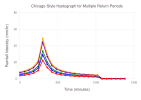

In [5]:
# stationary - observations

idf_mtl_trudeau = CSV.read("C:\\Users\\CM\\Polytechnique\\IDFCurves.jl\\data\\702S006-2.csv", DataFrame)
idf_mtl_trudeau = idf_mtl_trudeau[idf_mtl_trudeau.Year .>= 1955, :]
first(idf_mtl_trudeau, 5)

durations = [1/12, 1/6, 1/4, 1/2, 1, 2, 6, 12, 24]
tags = names(idf_mtl_trudeau)[2:10]
duration_dict = Dict(zip(tags, durations))
data = IDFdata(idf_mtl_trudeau, "Year", duration_dict)

pd = DependentScalingModel{GeneralScaling, UncorrelatedStructure, IdentityCopula}
f_dist = IDFCurves.fit_mle(pd, data, 1,  [20, 5, .04, .76, .07])

delta = offset(getmarginalmodel(f_dist))

return_period = [2, 5, 10, 50, 100]
storm_duration = 1440.0        # Total storm duration in minutes
time_step = 60.0               # Time step for the hyetograph in minutes
peak_time = 360.0              # Time of peak rainfall in the storm (6 hours)

# Generate and plot the hyetograph
p, hyetographs = plot_hyetographs(f_dist, return_period, storm_duration, time_step, peak_time)

total_rainfall = calculate_total_rainfall_multiple(hyetographs)
for (return_period, total_depth) in total_rainfall
    println("Return Period: $return_period years, Total Rainfall Depth: $total_depth mm")
end

p

file_name = "C:/Users/CM/Polytechnique/IDFCurves.jl/pictures/hyetograph/observations_stationary.png"
draw(PNG(file_name), p)

p2 = plot_cumulative_depth_curves(hyetographs)

file_name = "C:/Users/CM/Polytechnique/IDFCurves.jl/pictures/hydrograph/observations_stationary.png"
draw(PNG(file_name), p2)

p

Return Period: 5.0 years, Total Rainfall Depth: 134.57644076365784 mm
Return Period: 50.0 years, Total Rainfall Depth: 220.12127785053926 mm
Return Period: 2.0 years, Total Rainfall Depth: 100.33451109520915 mm
Return Period: 10.0 years, Total Rainfall Depth: 159.29770599604106 mm
Return Period: 100.0 years, Total Rainfall Depth: 248.7532474393328 mm


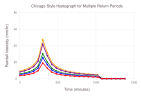

In [6]:
# stationary - simulations

member_data = df_annual_maxima["kda.csv"]
durations = [1, 2, 6, 12, 24]
tags = names(member_data)[2:6]
duration_dict = Dict(zip(tags, durations))

member_data = member_data[2021 .>=member_data.Year .>= 1955, :]
climex_data = IDFdata(member_data, "Year", duration_dict)

pd = DependentScalingModel{GeneralScaling, UncorrelatedStructure, IdentityCopula}
f_dist = IDFCurves.fit_mle(pd, climex_data, 1,  [20, 5, .04, .76, .07])

# Generate and plot the hyetograph
p, hyetographs = plot_hyetographs(f_dist, return_period, storm_duration, time_step, peak_time)

total_rainfall = calculate_total_rainfall_multiple(hyetographs)
for (return_period, total_depth) in total_rainfall
    println("Return Period: $return_period years, Total Rainfall Depth: $total_depth mm")
end

p

file_name = "C:/Users/CM/Polytechnique/IDFCurves.jl/pictures/hyetograph/simulations_stationary.png"
draw(PNG(file_name), p)

p2 = plot_cumulative_depth_curves(hyetographs)

file_name = "C:/Users/CM/Polytechnique/IDFCurves.jl/pictures/hydrograph/simulations_stationary.png"
draw(PNG(file_name), p2)

p

In [7]:
# non-stationary - observations

idf_mtl_trudeau = CSV.read("C:\\Users\\CM\\Polytechnique\\IDFCurves.jl\\data\\702S006-2.csv", DataFrame)
idf_mtl_trudeau = idf_mtl_trudeau[idf_mtl_trudeau.Year .>= 1955, :]
first(idf_mtl_trudeau, 5)

durations = [1/12, 1/6, 1/4, 1/2, 1, 2, 6, 12, 24]
tags = names(idf_mtl_trudeau)[2:10]
duration_dict = Dict(zip(tags, durations))
data = IDFdata(idf_mtl_trudeau, "Year", duration_dict)

pd = GeneralScaling(
    1.0,
    [Variable("t", idf_mtl_trudeau[:, Symbol("Year")])],
    Vector{Variable}(),
    Vector{Variable}(),
    Vector{Variable}(),
    Vector{Variable}(),
)
Σ = UncorrelatedStructure()
C = IdentityCopula
dsm = DependentScalingModel(pd, Σ, C) 
f_dist = IDFCurves.fit_mle(dsm, data, 1,  [20, 1, 5, .04, .76, .07])

return_period = [2, 5, 10, 50, 100]
storm_duration = 1440.0        # Total storm duration in minutes
time_step = 60.0               # Time step for the hyetograph in minutes
peak_time = 360.0              # Time of peak rainfall in the storm (halfway through)

# Generate and plot the hyetograph
p, hyetographs = plot_hyetographs(f_dist, return_period, storm_duration, time_step, peak_time, 1)

total_rainfall = calculate_total_rainfall_multiple(hyetographs)
for (return_period, total_depth) in total_rainfall
    println("Return Period: $return_period years, Total Rainfall Depth: $total_depth mm")
end

p

file_name = "C:/Users/CM/Polytechnique/IDFCurves.jl/pictures/hyetograph/observations_non_stationary.png"
draw(PNG(file_name), p)

p2 = plot_cumulative_depth_curves(hyetographs)

file_name = "C:/Users/CM/Polytechnique/IDFCurves.jl/pictures/hydrograph/observations_non_stationary.png"
draw(PNG(file_name), p2)

Return Period: 5.0 years, Total Rainfall Depth: 139.84594062046423 mm
Return Period: 50.0 years, Total Rainfall Depth: 210.44748534493647 mm
Return Period: 2.0 years, Total Rainfall Depth: 108.69052893203845 mm
Return Period: 10.0 years, Total Rainfall Depth: 161.2194128019065 mm
Return Period: 100.0 years, Total Rainfall Depth: 232.19998900733404 mm


In [8]:
# non-stationary - simulations (1955 - 2021)

rcp_data = CSV.read("C:\\Users\\CM\\Polytechnique\\IDFCurves.jl\\data\\RCPdata.csv", DataFrame)
rcp_data[!,"Cumulative RCP85"] = accumulate(+, rcp_data[!,"RCP85"])
rcp_data = rcp_data[2021 .>= rcp_data.Year .>= 1955, :]

member_data = df_annual_maxima["kda.csv"]
durations = [1, 2, 6, 12, 24]
tags = names(member_data)[2:6]
duration_dict = Dict(zip(tags, durations))

member_data = member_data[2021 .>=member_data.Year .>= 1955, :]
climex_data = IDFdata(member_data, "Year", duration_dict)

pd = GeneralScaling(
    1.0,
    [Variable("t", rcp_data[:, Symbol("Year")])],
    Vector{Variable}(),
    Vector{Variable}(),
    Vector{Variable}(),
    Vector{Variable}(),
)
Σ = UncorrelatedStructure()
C = IdentityCopula

dsm = DependentScalingModel(pd, Σ, C) 
f_dist = IDFCurves.fit_mle(dsm, climex_data, 6, [23, 1, 5.0, -.025, .5, 0.01], [nothing, nothing, nothing, nothing, nothing, log(delta)])


# Generate and plot the hyetograph
p, hyetographs = plot_hyetographs(f_dist, [2, 5, 10, 50, 100], storm_duration, time_step, peak_time, 1)

total_rainfall = calculate_total_rainfall_multiple(hyetographs)
for (return_period, total_depth) in total_rainfall
    println("Return Period: $return_period years, Total Rainfall Depth: $total_depth mm")
end

p

file_name = "C:/Users/CM/Polytechnique/IDFCurves.jl/pictures/hyetograph/simulations_non_stationary_1955-2021.png"
draw(PNG(file_name), p)


p2 = plot_cumulative_depth_curves(hyetographs)

file_name = "C:/Users/CM/Polytechnique/IDFCurves.jl/pictures/hydrograph/simulations_non_stationary_1955-2021.png"
draw(PNG(file_name), p2)

Return Period: 5.0 years, Total Rainfall Depth: 135.7774587109774 mm
Return Period: 50.0 years, Total Rainfall Depth: 219.67017480518635 mm
Return Period: 2.0 years, Total Rainfall Depth: 101.86546220262957 mm
Return Period: 10.0 years, Total Rainfall Depth: 160.13583079008168 mm
Return Period: 100.0 years, Total Rainfall Depth: 247.51884711632738 mm


In [9]:
# non-stationary - simulations (1955 - 2099)

rcp_data = CSV.read("C:\\Users\\CM\\Polytechnique\\IDFCurves.jl\\data\\RCPdata.csv", DataFrame)
rcp_data[!,"Cumulative RCP85"] = accumulate(+, rcp_data[!,"RCP85"])
rcp_data = rcp_data[2099 .>= rcp_data.Year .>= 1955, :]

member_data = df_annual_maxima["kda.csv"]
durations = [1, 2, 6, 12, 24]
tags = names(member_data)[2:6]
duration_dict = Dict(zip(tags, durations))

member_data = member_data[2099 .>=member_data.Year .>= 1955, :]
climex_data = IDFdata(member_data, "Year", duration_dict)

pd = GeneralScaling(
    1.0,
    [Variable("t", rcp_data[:, Symbol("Year")])],
    Vector{Variable}(),
    Vector{Variable}(),
    Vector{Variable}(),
    Vector{Variable}(),
)
Σ = UncorrelatedStructure()
C = IdentityCopula

dsm = DependentScalingModel(pd, Σ, C) 
f_dist = IDFCurves.fit_mle(dsm, climex_data, 6, [23, 1, 5.0, -.025, .5, 0.01], [nothing, nothing, nothing, nothing, nothing, log(delta)])


# Generate and plot the hyetograph
p, hyetographs = plot_hyetographs(f_dist, [2, 5, 10, 50, 100], storm_duration, time_step, peak_time, 1)

total_rainfall = calculate_total_rainfall_multiple(hyetographs)
for (return_period, total_depth) in total_rainfall
    println("Return Period: $return_period years, Total Rainfall Depth: $total_depth mm")
end

p

file_name = "C:/Users/CM/Polytechnique/IDFCurves.jl/pictures/hyetograph/simulations_non_stationary_1955-2099.png"
draw(PNG(file_name), p)

p2 = plot_cumulative_depth_curves(hyetographs)

file_name = "C:/Users/CM/Polytechnique/IDFCurves.jl/pictures/hydrograph/simulations_non_stationary_1955-2099.png"
draw(PNG(file_name), p2)

Return Period: 5.0 years, Total Rainfall Depth: 145.17208485494285 mm
Return Period: 50.0 years, Total Rainfall Depth: 248.7046466433367 mm
Return Period: 2.0 years, Total Rainfall Depth: 103.59198948553504 mm
Return Period: 10.0 years, Total Rainfall Depth: 175.1393704109812 mm
Return Period: 100.0 years, Total Rainfall Depth: 283.26070283511007 mm


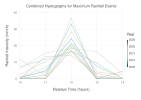

In [10]:
file_path = "C:\\Users\\CM\\Polytechnique\\IDFCurves.jl\\data\\702S006-15min.csv"
rainfall_data = CSV.read(file_path, DataFrame)
rainfall_data.Year = year.(rainfall_data.Date)
rainfall_data.Pcp .= rainfall_data.Pcp ./ 10

# Filter for May to October between 2008 and 2022
rainfall_data = filter(row -> month(row.Date) in 5:10 && row.Year in 2008:2022, rainfall_data)

rainfall_data[!, :FlooredDate] = floor.(rainfall_data.Date, Hour(1))
hourly_data = combine(groupby(rainfall_data, :FlooredDate), :Pcp => sum => :PcpSum)
rename!(hourly_data, :FlooredDate => :Date)
hourly_data.Year = year.(hourly_data.Date)

grouped = groupby(hourly_data, :Year)
max_intensity_hyetographs = DataFrame()

for g in grouped
    g = filter(row -> !ismissing(row.PcpSum), g)
    max_index = argmax(g.PcpSum)
    if !ismissing(g[max_index, :PcpSum])
        max_time = g[max_index, :Date]
        
        # Extract 24-hour period around the max intensity
        start_time = max_time - Hour(12)
        end_time = max_time + Hour(12)
        storm_hyetograph = filter(row -> row.Date >= start_time && row.Date <= end_time, g)

        storm_hyetograph[!, :RelativeTime] .= (storm_hyetograph.Date .- start_time) ./ Hour(1)
        storm_hyetograph[!, :Year] .= year(max_time)
        
        append!(max_intensity_hyetographs, storm_hyetograph)
    end
end

max_intensity_hyetographs = filter(row -> 10 <= row.RelativeTime <= 14, max_intensity_hyetographs)

p = plot(
    layer(
        max_intensity_hyetographs,
        x = :RelativeTime,
        y = :PcpSum,
        color = :Year,
        Geom.line
    ),
    Guide.xlabel("Relative Time (hours)"),
    Guide.ylabel("Rainfall Intensity (mm/h)"),
    Guide.title("Combined Hyetographs for Maximum Rainfall Events"),
    Theme(
        panel_fill = color("white"),  # Set the panel background to white
        background_color = color("white")  # Set the overall background to white
     )
)

display(p)

2008-06-23T19:30:00
2009-07-06T08:30:00
2010-06-21T20:30:00
2011-08-15T19:30:00
2012-06-28T22:30:00
2013-07-24T03:30:00
2014-06-18T21:30:00
2015-08-18T19:30:00
2016-06-30T15:30:00
2017-06-17T21:30:00
2018-05-27T01:30:00
2019-08-26T01:30:00
2020-06-27T18:30:00
2021-09-02T22:30:00
2022-06-30T09:30:00


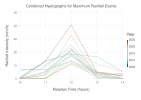

In [11]:
file_path = "C:\\Users\\CM\\Polytechnique\\IDFCurves.jl\\data\\climEx_hrs\\kda.csv"
rainfall_data = CSV.read(file_path, DataFrame)
rainfall_data.Year = year.(rainfall_data.Date)
rainfall_data.Month = month.(rainfall_data.Date)

# Filter for the years 2008 to 2022 and months May to October
filtered_data = filter(row -> row.Year in 2008:2022 && row.Month in 5:10, rainfall_data)

hyetographs = DataFrame[]
grouped = groupby(filtered_data, :Year)

for g in grouped
    year = g.Year[1]
    max_index = argmax(g.Pluie)
    max_time = g[max_index, :Date]

    println(max_time)
    
    start_time = max_time - Hour(12)
    end_time = max_time + Hour(12)
    storm_hyetograph = filter(row -> row.Date >= start_time && row.Date <= end_time, g)

    storm_hyetograph[!, :RelativeTime] = (storm_hyetograph.Date .- start_time) ./ Hour(1)
    storm_hyetograph[!, :Year] .= year

    push!(hyetographs, storm_hyetograph)
end

combined_hyetographs = vcat(hyetographs...)

# Filter for relative time between 7 and 14 hours
filtered_hyetographs = filter(row -> 10 <= row.RelativeTime <= 14, combined_hyetographs)

p = plot(
    layer(
        filtered_hyetographs,
        x = :RelativeTime,
        y = :Pluie,
        color = :Year,
        Geom.line
    ),
    Guide.xlabel("Relative Time (hours)"),
    Guide.ylabel("Rainfall Intensity (mm/h)"),
    Guide.title("Combined Hyetographs for Maximum Rainfall Events"),
    Theme(
        panel_fill = color("white"),  # Set the panel background to white
        background_color = color("white")  # Set the overall background to white
     )
)

display(p)

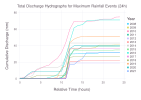

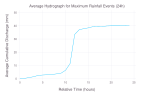

In [12]:
file_path = "C:\\Users\\CM\\Polytechnique\\IDFCurves.jl\\data\\702S006-15min.csv"
rainfall_data = CSV.read(file_path, DataFrame)
rainfall_data.Year = year.(rainfall_data.Date)
rainfall_data.Pcp .= rainfall_data.Pcp ./ 10

# Filter for May to October between 2008 and 2022
rainfall_data = filter(row -> month(row.Date) in 5:10 && row.Year in 2008:2022, rainfall_data)

rainfall_data[!, :FlooredDate] = floor.(rainfall_data.Date, Hour(1))
hourly_data = combine(groupby(rainfall_data, :FlooredDate), :Pcp => sum => :PcpSum)
rename!(hourly_data, :FlooredDate => :Date)
hourly_data.Year = year.(hourly_data.Date)

grouped = groupby(hourly_data, :Year)
max_intensity_hyetographs = DataFrame()

for g in grouped
    g = filter(row -> !ismissing(row.PcpSum), g)
    max_index = argmax(g.PcpSum)
    
    if !ismissing(g[max_index, :PcpSum])
        max_time = g[max_index, :Date]
        
        start_time = max_time - Hour(12)
        end_time = max_time + Hour(12)
        storm_hyetograph = filter(row -> row.Date >= start_time && row.Date <= end_time, g)

        storm_hyetograph[!, :RelativeTime] .= (storm_hyetograph.Date .- start_time) ./ Hour(1)
        storm_hyetograph[!, :Year] .= year(max_time)
        
        storm_hyetograph[!, :CumulativeDischarge] = cumsum(skipmissing(storm_hyetograph.PcpSum))

        append!(max_intensity_hyetographs, storm_hyetograph)
    end
end

p = plot(
    max_intensity_hyetographs,
    x = :RelativeTime,
    y = :CumulativeDischarge,
    color = :Year,
    Geom.line,
    Scale.color_discrete,
    Guide.xlabel("Relative Time (hours)"),
    Guide.ylabel("Cumulative Discharge (mm)"),
    Guide.title("Total Discharge Hydrographs for Maximum Rainfall Events (24h)"),
    Theme(
        panel_fill = color("white"),  # Set the panel background to white
        background_color = color("white")  # Set the overall background to white
     )
)

display(p)

average_hydrograph = combine(
    groupby(max_intensity_hyetographs, :RelativeTime),
    :CumulativeDischarge => mean => :AverageCumulativeDischarge
)

p2 = plot(
    average_hydrograph,
    x = :RelativeTime,
    y = :AverageCumulativeDischarge,
    Geom.line,
    Guide.xlabel("Relative Time (hours)"),
    Guide.ylabel("Average Cumulative Discharge (mm)"),
    Guide.title("Average Hydrograph for Maximum Rainfall Events (24h)"),
    Theme(
        panel_fill = color("white"),  # Set the panel background to white
        background_color = color("white")  # Set the overall background to white
     )
)


display(p2)

file_name = "C:/Users/CM/Polytechnique/IDFCurves.jl/pictures/hydrograph/observations.png"
draw(PNG(file_name), p2)

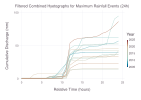

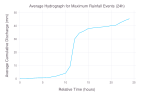

In [13]:
file_path = "C:\\Users\\CM\\Polytechnique\\IDFCurves.jl\\data\\climEx_hrs\\kda.csv"
rainfall_data = CSV.read(file_path, DataFrame)

rainfall_data.Year = year.(rainfall_data.Date)
rainfall_data.Month = month.(rainfall_data.Date)

# Filter for the years 2008 to 2022 and months May to October
filtered_data = filter(row -> row.Year in 2008:2022 && row.Month in 5:10, rainfall_data)

hyetographs = DataFrame[]
grouped = groupby(filtered_data, :Year)

for g in grouped
    year = g.Year[1]
    max_index = argmax(g.Pluie)
    max_time = g[max_index, :Date]
    
    start_time = max_time - Hour(12)
    end_time = max_time + Hour(12)
    storm_hyetograph = filter(row -> row.Date >= start_time && row.Date <= end_time, g)
    
    storm_hyetograph[!, :RelativeTime] = (storm_hyetograph.Date .- start_time) ./ Hour(1)
    storm_hyetograph[!, :CumulativeDischarge] = cumsum(skipmissing(storm_hyetograph.Pluie))
    storm_hyetograph[!, :Year] .= year

    push!(hyetographs, storm_hyetograph)
end

combined_hyetographs = vcat(hyetographs...)

p = plot(
    layer(
        combined_hyetographs,
        x = :RelativeTime,
        y = :CumulativeDischarge,
        color = :Year,
        Geom.line
    ),
    Guide.xlabel("Relative Time (hours)"),
    Guide.ylabel("Cumulative Discharge (mm)"),
    Guide.title("Filtered Combined Hyetographs for Maximum Rainfall Events (24h)"),
    Theme(
        panel_fill = color("white"),  # Set the panel background to white
        background_color = color("white")  # Set the overall background to white
     )
)

display(p)

average_hydrograph = combine(
    groupby(combined_hyetographs, :RelativeTime),
    :CumulativeDischarge => mean => :AverageCumulativeDischarge
)

p2 = plot(
    average_hydrograph,
    x = :RelativeTime,
    y = :AverageCumulativeDischarge,
    Geom.line,
    Guide.xlabel("Relative Time (hours)"),
    Guide.ylabel("Average Cumulative Discharge (mm)"),
    Guide.title("Average Hydrograph for Maximum Rainfall Events (24h)"),
    Theme(
        panel_fill = color("white"),  # Set the panel background to white
        background_color = color("white")  # Set the overall background to white
     )
)


display(p2)

file_name = "C:/Users/CM/Polytechnique/IDFCurves.jl/pictures/hydrograph/simulations.png"
draw(PNG(file_name), p2)